# ShockTube EnKF DA Experiment Visualization

Load and visualize the high-resolution shock-tube results with EnKF data assimilation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 10)

## Load experiment results

In [2]:
# Load snapshots and metrics
run_dir = Path('../runs/shocktube_hr_enkf')
snapshots = np.load(run_dir / 'snapshots.npz')
metrics = pd.read_csv(run_dir / 'metrics.csv')

with open(run_dir / 'config.json') as f:
    config = json.load(f)

# Extract data
truth = snapshots['truth']
forecast_mean = snapshots['forecast_mean']
analysis_mean = snapshots['analysis_mean']
observations = snapshots['observations']

nx = config['nx']
steps = config['steps']

print(f"Grid size: {nx} cells")
print(f"Time steps: {steps}")
print(f"Ensemble members: {config['Ne']}")
print(f"Sensor locations: {config['observation']['sensor_idx']}")
print(f"\nMetrics shape: {metrics.shape}")
print(f"Truth shape: {truth.shape}")

Grid size: 128 cells
Time steps: 10
Ensemble members: 16
Sensor locations: [20, 40, 60, 80, 100]

Metrics shape: (10, 5)
Truth shape: (11, 384)


## Helper: Convert conservative to primitive variables

In [3]:
def cons_to_prim(U_flat, nx, gamma=1.4):
    """Convert conservative U (rho, rho*u, E) to primitives (rho, u, p)."""
    U = U_flat.reshape(nx, 3)
    rho = U[:, 0]
    u = U[:, 1] / rho
    E = U[:, 2]
    p = (gamma - 1.0) * (E - 0.5 * rho * u ** 2)
    return rho, u, p

# Convert all snapshots to primitive
truth_prim = [cons_to_prim(truth[k], nx) for k in range(truth.shape[0])]
forecast_prim = [cons_to_prim(forecast_mean[k], nx) for k in range(forecast_mean.shape[0])]
analysis_prim = [cons_to_prim(analysis_mean[k], nx) for k in range(analysis_mean.shape[0])]

print("Converted to primitive variables (rho, u, p)")

Converted to primitive variables (rho, u, p)


## Plot 1: Density evolution (truth vs forecast vs analysis)

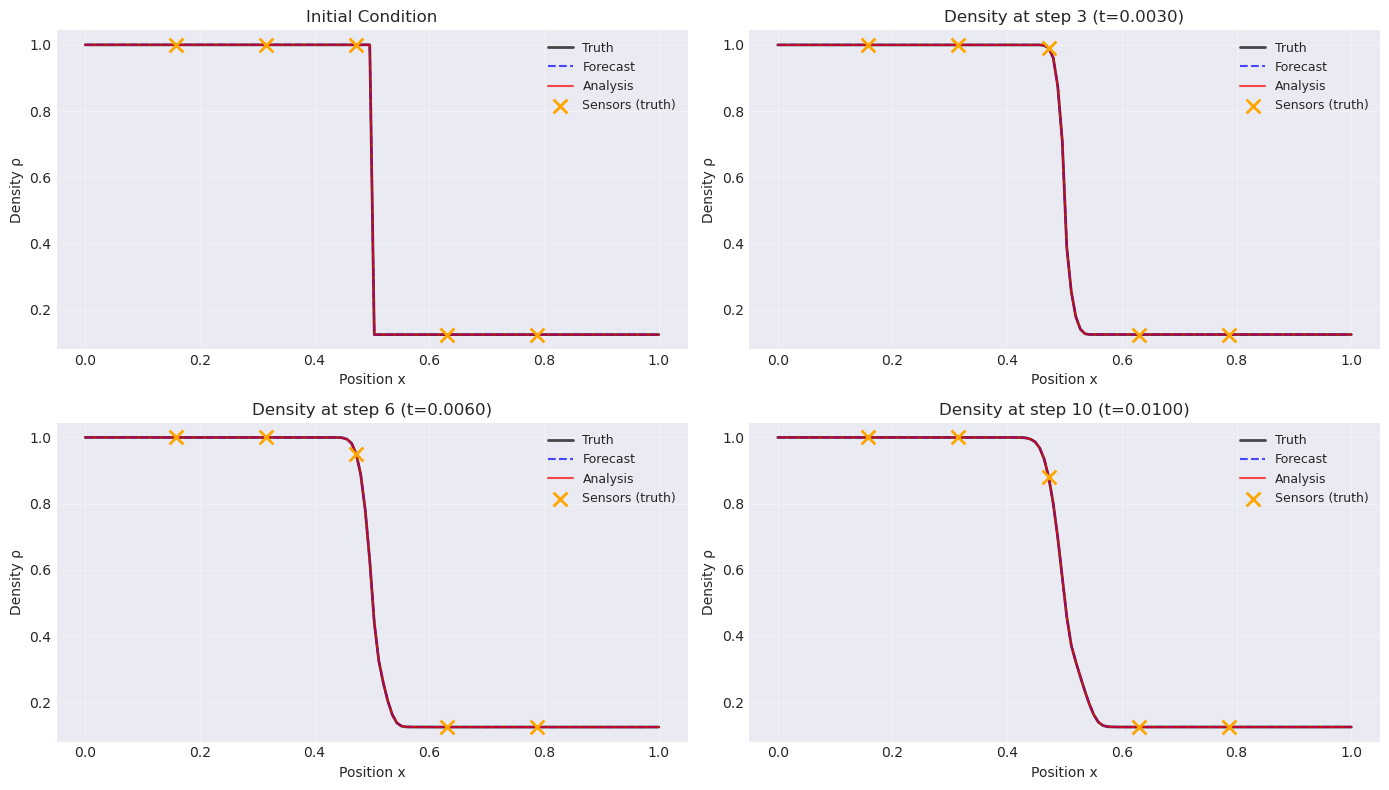

Density evolution plot saved.


In [5]:
x = np.linspace(0, 1, nx)

# Select a few time steps to display
time_indices = [0, 3, 6, 10]  # initial, intermediate, final

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, k in enumerate(time_indices):
    if k > truth.shape[0] - 1:
        continue
    ax = axes[idx]
    rho_truth, u_truth, p_truth = truth_prim[k]
    rho_fcst, u_fcst, p_fcst = forecast_prim[k]
    rho_anal, u_anal, p_anal = analysis_prim[k]
    
    ax.plot(x, rho_truth, 'k-', linewidth=2, label='Truth', alpha=0.7)
    ax.plot(x, rho_fcst, 'b--', linewidth=1.5, label='Forecast', alpha=0.7)
    ax.plot(x, rho_anal, 'r-', linewidth=1.5, label='Analysis', alpha=0.7)
    
    # Mark sensor locations
    sensor_idx = config['observation']['sensor_idx']
    sensor_x = x[sensor_idx]
    ax.scatter(sensor_x, rho_truth[sensor_idx], color='orange', s=100, marker='x', linewidth=2, label='Sensors (truth)', zorder=10)
    
    time_val = metrics.iloc[max(0, k-1)]["time"] if k > 0 else 0.0
    ax.set_title(f'Density at step {k} (t={time_val:.4f})' if k > 0 else 'Initial Condition')
    ax.set_xlabel('Position x')
    ax.set_ylabel('Density ρ')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../runs/shocktube_hr_enkf/density_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Density evolution plot saved.")

## Plot 2: Velocity evolution

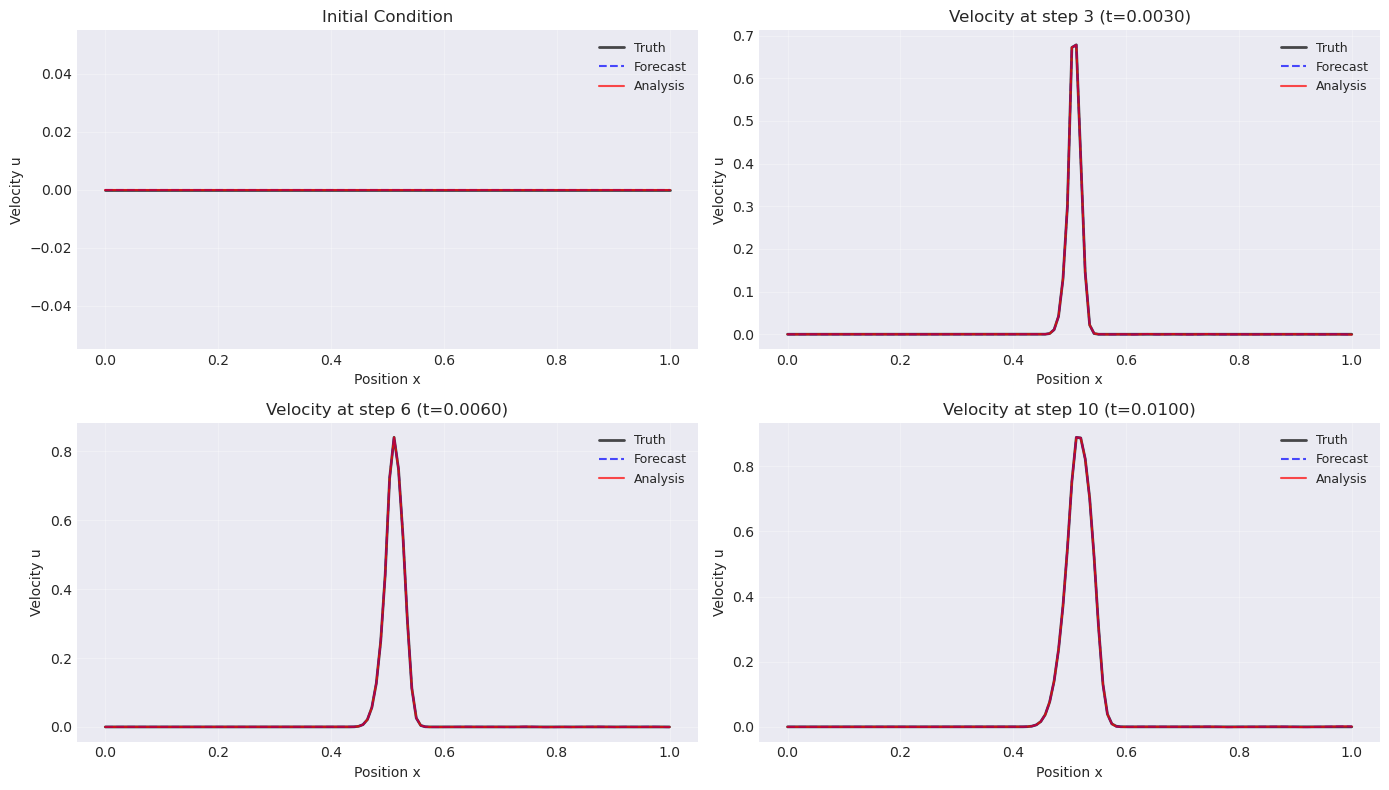

Velocity evolution plot saved.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, k in enumerate(time_indices):
    if k > truth.shape[0] - 1:
        continue
    ax = axes[idx]
    rho_truth, u_truth, p_truth = truth_prim[k]
    rho_fcst, u_fcst, p_fcst = forecast_prim[k]
    rho_anal, u_anal, p_anal = analysis_prim[k]
    
    ax.plot(x, u_truth, 'k-', linewidth=2, label='Truth', alpha=0.7)
    ax.plot(x, u_fcst, 'b--', linewidth=1.5, label='Forecast', alpha=0.7)
    ax.plot(x, u_anal, 'r-', linewidth=1.5, label='Analysis', alpha=0.7)
    
    time_val = metrics.iloc[max(0, k-1)]["time"] if k > 0 else 0.0
    ax.set_title(f'Velocity at step {k} (t={time_val:.4f})' if k > 0 else 'Initial Condition')
    ax.set_xlabel('Position x')
    ax.set_ylabel('Velocity u')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../runs/shocktube_hr_enkf/velocity_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Velocity evolution plot saved.")

## Plot 3: Pressure evolution

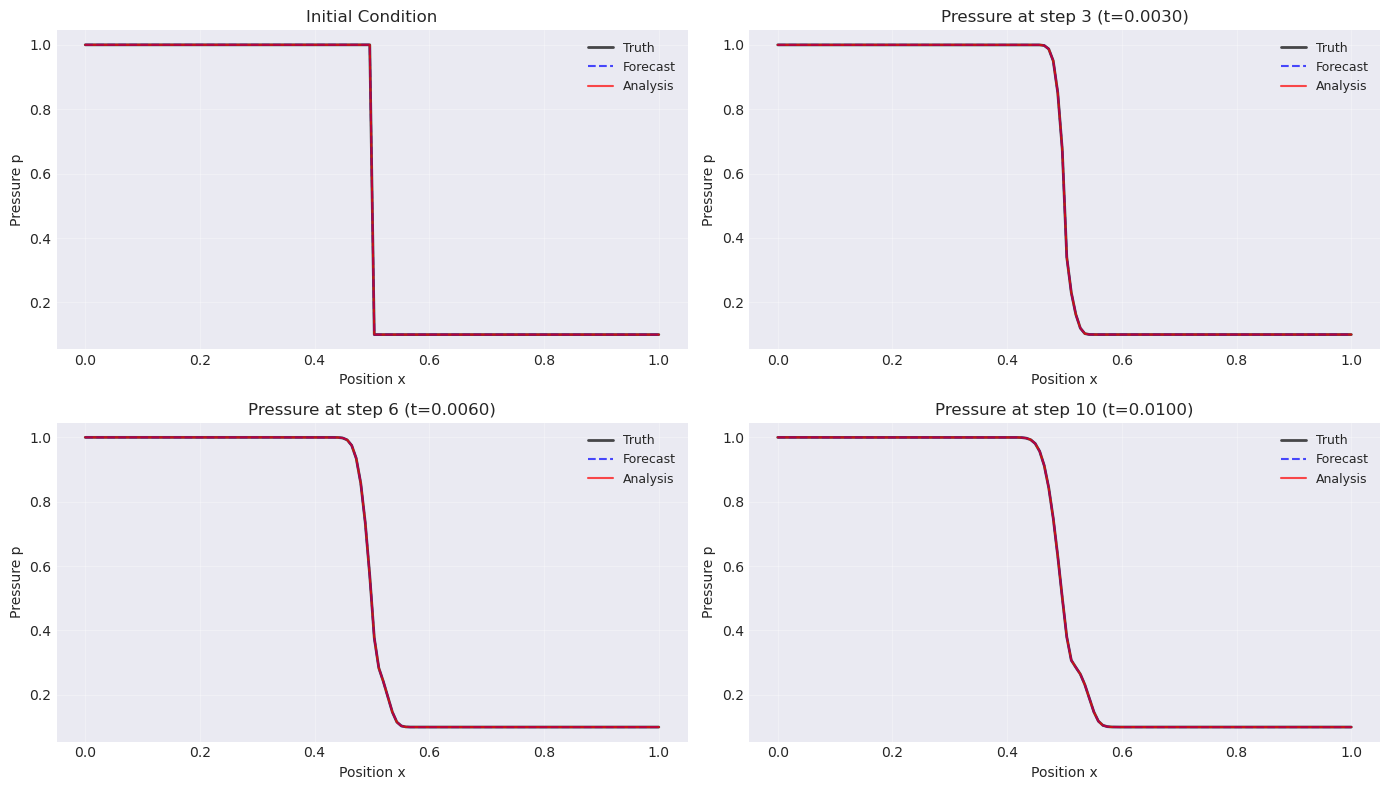

Pressure evolution plot saved.


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, k in enumerate(time_indices):
    if k > truth.shape[0] - 1:
        continue
    ax = axes[idx]
    rho_truth, u_truth, p_truth = truth_prim[k]
    rho_fcst, u_fcst, p_fcst = forecast_prim[k]
    rho_anal, u_anal, p_anal = analysis_prim[k]
    
    ax.plot(x, p_truth, 'k-', linewidth=2, label='Truth', alpha=0.7)
    ax.plot(x, p_fcst, 'b--', linewidth=1.5, label='Forecast', alpha=0.7)
    ax.plot(x, p_anal, 'r-', linewidth=1.5, label='Analysis', alpha=0.7)
    
    time_val = metrics.iloc[max(0, k-1)]["time"] if k > 0 else 0.0
    ax.set_title(f'Pressure at step {k} (t={time_val:.4f})' if k > 0 else 'Initial Condition')
    ax.set_xlabel('Position x')
    ax.set_ylabel('Pressure p')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../runs/shocktube_hr_enkf/pressure_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Pressure evolution plot saved.")

## Plot 4: Error metrics time series

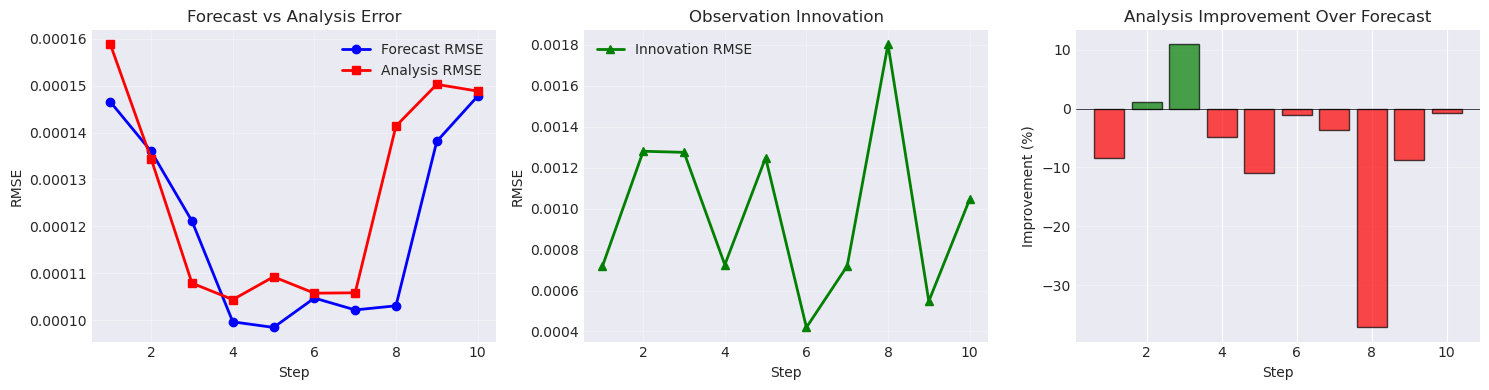


Average analysis improvement: -6.33%


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# RMSE Forecast vs Analysis
ax = axes[0]
ax.plot(metrics['step'], metrics['rmse_forecast'], 'b-o', linewidth=2, markersize=6, label='Forecast RMSE')
ax.plot(metrics['step'], metrics['rmse_analysis'], 'r-s', linewidth=2, markersize=6, label='Analysis RMSE')
ax.set_xlabel('Step')
ax.set_ylabel('RMSE')
ax.set_title('Forecast vs Analysis Error')
ax.legend()
ax.grid(True, alpha=0.3)

# Innovation
ax = axes[1]
ax.plot(metrics['step'], metrics['rmse_innov'], 'g-^', linewidth=2, markersize=6, label='Innovation RMSE')
ax.set_xlabel('Step')
ax.set_ylabel('RMSE')
ax.set_title('Observation Innovation')
ax.legend()
ax.grid(True, alpha=0.3)

# Analysis improvement
ax = axes[2]
improvement = (metrics['rmse_forecast'] - metrics['rmse_analysis']) / metrics['rmse_forecast'] * 100
colors = ['green' if x > 0 else 'red' for x in improvement]
ax.bar(metrics['step'], improvement, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.set_xlabel('Step')
ax.set_ylabel('Improvement (%)')
ax.set_title('Analysis Improvement Over Forecast')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../runs/shocktube_hr_enkf/error_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAverage analysis improvement: {improvement.mean():.2f}%")

## Plot 5: Shock front tracking (final state)

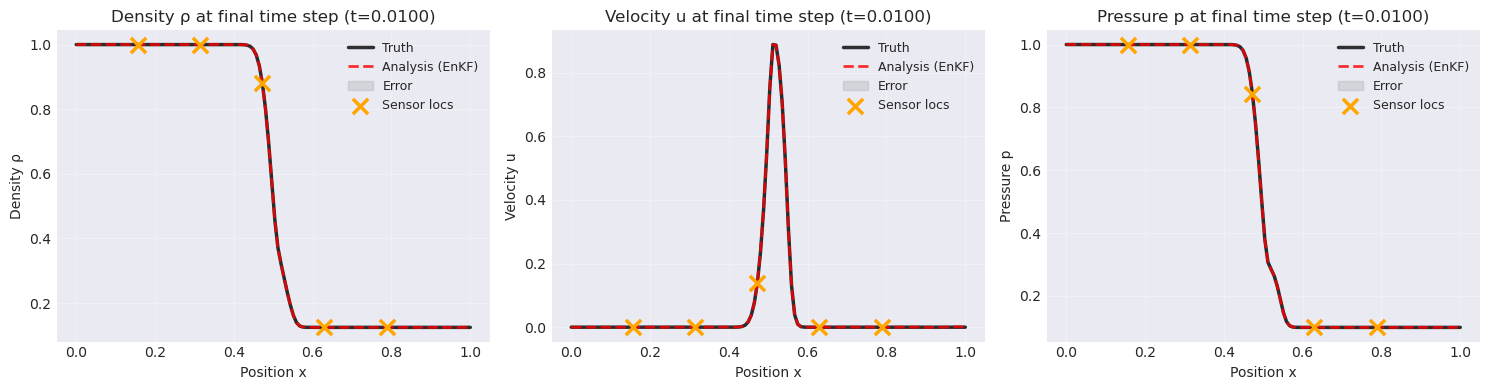

Final state comparison plot saved.


In [10]:
k_final = truth.shape[0] - 1
rho_truth, u_truth, p_truth = truth_prim[k_final]
rho_anal, u_anal, p_anal = analysis_prim[k_final]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for var_name, var_truth, var_anal, ax in zip(
    ['Density ρ', 'Velocity u', 'Pressure p'],
    [rho_truth, u_truth, p_truth],
    [rho_anal, u_anal, p_anal],
    axes
):
    ax.plot(x, var_truth, 'k-', linewidth=2.5, label='Truth', alpha=0.8)
    ax.plot(x, var_anal, 'r--', linewidth=2, label='Analysis (EnKF)', alpha=0.8)
    ax.fill_between(x, var_truth, var_anal, alpha=0.2, color='gray', label='Error')
    
    # Mark sensors
    sensor_idx = config['observation']['sensor_idx']
    ax.scatter(x[sensor_idx], var_truth[sensor_idx], color='orange', s=120, marker='x', linewidth=2.5, label='Sensor locs', zorder=10)
    
    ax.set_xlabel('Position x')
    ax.set_ylabel(var_name)
    ax.set_title(f'{var_name} at final time step (t={metrics.iloc[-1, 1]:.4f})')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../runs/shocktube_hr_enkf/final_state.png', dpi=150, bbox_inches='tight')
plt.show()

print("Final state comparison plot saved.")

## Summary statistics

In [11]:
print("=" * 60)
print("EXPERIMENT SUMMARY: Shock-Tube EnKF (High-Resolution)")
print("=" * 60)
print(f"\nConfiguration:")
print(f"  Grid size: {nx} cells")
print(f"  Ensemble members: {config['Ne']}")
print(f"  Time steps: {config['steps']}")
print(f"  Sensors: {len(config['observation']['sensor_idx'])} density probes")

print(f"\nError Metrics Summary:")
print(f"  Mean forecast RMSE: {metrics['rmse_forecast'].mean():.6e}")
print(f"  Mean analysis RMSE:  {metrics['rmse_analysis'].mean():.6e}")
print(f"  Mean innovation:     {metrics['rmse_innov'].mean():.6e}")

print(f"\nAnalysis Performance:")
improvement = (metrics['rmse_forecast'] - metrics['rmse_analysis']) / metrics['rmse_forecast'] * 100
print(f"  Mean improvement over forecast: {improvement.mean():.2f}%")
print(f"  Min improvement: {improvement.min():.2f}%")
print(f"  Max improvement: {improvement.max():.2f}%")

print(f"\nFinal State Errors:")
k_final = truth.shape[0] - 1
error_rho = np.linalg.norm(analysis_prim[k_final][0] - truth_prim[k_final][0])
error_u = np.linalg.norm(analysis_prim[k_final][1] - truth_prim[k_final][1])
error_p = np.linalg.norm(analysis_prim[k_final][2] - truth_prim[k_final][2])
print(f"  Density L2-norm error: {error_rho:.6e}")
print(f"  Velocity L2-norm error: {error_u:.6e}")
print(f"  Pressure L2-norm error: {error_p:.6e}")

print(f"\nOutput files saved to: {run_dir}")
print("=" * 60)

EXPERIMENT SUMMARY: Shock-Tube EnKF (High-Resolution)

Configuration:
  Grid size: 128 cells
  Ensemble members: 16
  Time steps: 10
  Sensors: 5 density probes

Error Metrics Summary:
  Mean forecast RMSE: 1.197417e-04
  Mean analysis RMSE:  1.266698e-04
  Mean innovation:     9.781369e-04

Analysis Performance:
  Mean improvement over forecast: -6.33%
  Min improvement: -37.22%
  Max improvement: 10.93%

Final State Errors:
  Density L2-norm error: 1.346941e-03
  Velocity L2-norm error: 3.951457e-03
  Pressure L2-norm error: 9.684715e-04

Output files saved to: ../runs/shocktube_hr_enkf
